# 1.0 Blob Base Fee vs Calldata Correlation

This notebook checks whether the EIP-4844 blob base fee is correlated with block-level calldata usage over the current 500-block sample.

The immediate question is:

```text
Do high blob base-fee blocks also have high calldata bytes or calldata gas?
```

This is a descriptive historical check, not a demand model. The blob base fee is a state variable with memory, while calldata bytes are same-block execution-payload data. A weak same-block correlation does not prove there is no substitution between blobs and calldata; it only says that in this short sample, these two block-level series do or do not move together.

In [1]:
import json
import os
from pathlib import Path
import sys
import urllib.request

import clickhouse_connect
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from sim.xatu_calldata import query_xatu_calldata_by_block

pd.options.display.float_format = "{:,.6f}".format

load_dotenv(PROJECT_ROOT / ".env")
missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
if missing:
    raise RuntimeError("Missing .env values: " + ", ".join(missing))

RPC_URL = os.environ.get("ALCHEMY_RPC") or os.environ.get("RPC_URL")
if not RPC_URL:
    raise RuntimeError("Missing ALCHEMY_RPC or RPC_URL in .env for eth_feeHistory")

CLICKHOUSE_RAW_HOST = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")
raw_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_RAW_HOST,
    port=443,
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)

print("raw", CLICKHOUSE_RAW_HOST)
print("rpc", "configured")

raw clickhouse-raw.xatu.ethpandaops.io
rpc configured


## Parameters

The block range matches the current 500-block sample used by the bandwidth and replay notebooks.

Data sources:

- Xatu `canonical_beacon_block` gives `blob_gas_used` and `excess_blob_gas`.
- Xatu calldata helpers give calldata bytes and zero/nonzero byte counts.
- JSON-RPC `eth_feeHistory` gives the actual `baseFeePerBlobGas` for each historical block.

I originally checked whether Xatu exposed the blob base fee directly. In the raw tables used here, it exposes the ingredients/diagnostics but not the actual base-fee field, so this notebook uses RPC for the fee and Xatu for the block data.

In [2]:
NETWORK = "mainnet"
START_BLOCK = 24_120_001
N_BLOCKS = 500
BLOCKS = list(range(START_BLOCK, START_BLOCK + N_BLOCKS))

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

CALLDATA_CSV = DATA_DIR / f"xatu_calldata_{min(BLOCKS)}_{max(BLOCKS)}.csv"
XATU_BLOB_GAS_CSV = DATA_DIR / f"xatu_blob_gas_fields_{min(BLOCKS)}_{max(BLOCKS)}.csv"
RPC_BLOB_BASE_FEE_CSV = DATA_DIR / f"rpc_blob_base_fee_{min(BLOCKS)}_{max(BLOCKS)}.csv"
JOINED_CSV = DATA_DIR / f"blob_base_fee_calldata_{min(BLOCKS)}_{max(BLOCKS)}.csv"
CORR_CSV = DATA_DIR / f"blob_base_fee_calldata_correlations_{min(BLOCKS)}_{max(BLOCKS)}.csv"
SUMMARY_CSV = DATA_DIR / f"blob_base_fee_calldata_summary_{min(BLOCKS)}_{max(BLOCKS)}.csv"

OUT_TIMESERIES_PLOT = PLOTS_DIR / f"blob_base_fee_calldata_timeseries_{min(BLOCKS)}_{max(BLOCKS)}.png"
OUT_SCATTER_BYTES_PLOT = PLOTS_DIR / f"blob_base_fee_calldata_bytes_scatter_{min(BLOCKS)}_{max(BLOCKS)}.png"
OUT_SCATTER_GAS_PLOT = PLOTS_DIR / f"blob_base_fee_calldata_gas_scatter_{min(BLOCKS)}_{max(BLOCKS)}.png"
OUT_LAG_PLOT = PLOTS_DIR / f"blob_base_fee_calldata_lag_correlations_{min(BLOCKS)}_{max(BLOCKS)}.png"

WRITE_CSV = True
min(BLOCKS), max(BLOCKS), len(BLOCKS)

(24120001, 24120500, 500)

## Load Calldata From Xatu

Calldata comes from the same Xatu path as the bandwidth notebook. The raw byte total is from the beacon execution-payload transaction table, and zero/nonzero counts come from `execution_transaction` after matching transaction count and byte count against the beacon payload.

For this correlation check, `calldata_gas_4_16` is the standard calldata gas:

```text
4 * zero_calldata_bytes + 16 * nonzero_calldata_bytes
```

This is intentionally not the EIP-7623 or EIP-7976 floor calculation; the purpose here is to compare blob base fee against raw calldata pressure.

In [3]:
if CALLDATA_CSV.exists():
    calldata = pd.read_csv(CALLDATA_CSV)
    print("loaded", CALLDATA_CSV)
else:
    calldata = query_xatu_calldata_by_block(raw_client, BLOCKS, network=NETWORK)
    if WRITE_CSV:
        calldata.to_csv(CALLDATA_CSV, index=False)
        print(CALLDATA_CSV)

calldata["calldata_zero_bytes"] = calldata["calldata_zero_bytes"].astype("int64")
calldata["calldata_nonzero_bytes"] = calldata["calldata_nonzero_bytes"].astype("int64")
calldata["calldata_bytes"] = calldata["calldata_bytes"].astype("int64")
calldata["calldata_gas_4_16"] = (
    4 * calldata["calldata_zero_bytes"]
    + 16 * calldata["calldata_nonzero_bytes"]
)
calldata["calldata_nonzero_share"] = np.where(
    calldata["calldata_bytes"] > 0,
    calldata["calldata_nonzero_bytes"] / calldata["calldata_bytes"],
    0,
)

calldata_cols = [
    "block_number",
    "slot",
    "n_txs_from_payload",
    "calldata_bytes",
    "calldata_zero_bytes",
    "calldata_nonzero_bytes",
    "calldata_gas_4_16",
    "calldata_nonzero_share",
    "blob_versioned_hash_count",
    "blob_versioned_hash_bytes",
]
calldata = calldata[calldata_cols].sort_values("block_number").reset_index(drop=True)
calldata.head()

loaded /Users/william/PycharmProjects/eip-7999-research/data/xatu_calldata_24120001_24120500.csv


,block_number,slot,n_txs_from_payload,calldata_bytes,calldata_zero_bytes,calldata_nonzero_bytes,calldata_gas_4_16,calldata_nonzero_share,blob_versioned_hash_count,blob_versioned_hash_bytes
0,24120001,13350651,344,238525,144495,94030,2082460,0.394214,13,416
1,24120002,13350652,179,44492,29852,14640,353648,0.329048,6,192
2,24120003,13350653,489,136567,86377,50190,1148548,0.367512,4,128
3,24120004,13350654,232,70460,44058,26402,598664,0.374709,9,288
4,24120005,13350655,250,46996,30210,16786,389416,0.357179,0,0


## Pull Blob Gas Fields From Xatu

Xatu gives `blob_gas_used` and `excess_blob_gas` for each execution payload. These are useful diagnostics and should line up with RPC `blobGasUsedRatio`, but the actual base fee is pulled from RPC in the next section.

In [4]:
if XATU_BLOB_GAS_CSV.exists():
    xatu_blob = pd.read_csv(XATU_BLOB_GAS_CSV)
    print("loaded", XATU_BLOB_GAS_CSV)
else:
    xatu_blob = raw_client.query_df(
        """
        SELECT
            execution_payload_block_number AS block_number,
            slot,
            slot_start_date_time AS timestamp,
            execution_payload_blob_gas_used AS blob_gas_used,
            execution_payload_excess_blob_gas AS excess_blob_gas
        FROM default.canonical_beacon_block FINAL
        WHERE meta_network_name = {network:String}
          AND execution_payload_block_number IN {blocks:Array(UInt64)}
        ORDER BY block_number
        """,
        parameters={"network": NETWORK, "blocks": BLOCKS},
    )
    if WRITE_CSV:
        xatu_blob.to_csv(XATU_BLOB_GAS_CSV, index=False)
        print(XATU_BLOB_GAS_CSV)

xatu_blob["block_number"] = xatu_blob["block_number"].astype("int64")
xatu_blob["slot"] = xatu_blob["slot"].astype("int64")
xatu_blob["blob_gas_used"] = xatu_blob["blob_gas_used"].astype("int64")
xatu_blob["excess_blob_gas"] = xatu_blob["excess_blob_gas"].astype("int64")
xatu_blob["blob_count"] = xatu_blob["blob_gas_used"] / 131_072
xatu_blob.head()

/Users/william/PycharmProjects/eip-7999-research/data/xatu_blob_gas_fields_24120001_24120500.csv


,block_number,slot,timestamp,blob_gas_used,excess_blob_gas,blob_count
0,24120001,13350651,2025-12-29 18:10:35,1703936,125362284,13.000000
1,24120002,13350652,2025-12-29 18:10:47,786432,125930262,6.000000
2,24120003,13350653,2025-12-29 18:10:59,524288,126192406,4.000000
3,24120004,13350654,2025-12-29 18:11:11,1179648,126367168,9.000000
4,24120005,13350655,2025-12-29 18:11:23,0,126760384,0.000000


## Pull Actual Blob Base Fee From RPC

`eth_feeHistory` returns `baseFeePerBlobGas`. For `blockCount = 500` and `newestBlock = END_BLOCK`, it returns 501 blob base-fee values: one for each requested block plus the next block. The notebook uses the first 500 values as the fee for blocks `START_BLOCK..END_BLOCK` and keeps the extra next-block value separately as `next_blob_base_fee_per_gas`.

In [5]:
def rpc_call(method: str, params: list) -> dict:
    payload = {"jsonrpc": "2.0", "id": 1, "method": method, "params": params}
    request = urllib.request.Request(
        RPC_URL,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
    )
    with urllib.request.urlopen(request, timeout=60) as response:
        data = json.load(response)
    if "error" in data:
        raise RuntimeError(data["error"])
    return data["result"]

if RPC_BLOB_BASE_FEE_CSV.exists():
    rpc_fee = pd.read_csv(RPC_BLOB_BASE_FEE_CSV)
    print("loaded", RPC_BLOB_BASE_FEE_CSV)
else:
    result = rpc_call("eth_feeHistory", [hex(len(BLOCKS)), hex(max(BLOCKS)), []])
    oldest_block = int(result["oldestBlock"], 16)
    base_fee_values = [int(value, 16) for value in result["baseFeePerBlobGas"]]
    if oldest_block != min(BLOCKS):
        raise RuntimeError(f"Unexpected oldestBlock {oldest_block}; expected {min(BLOCKS)}")
    if len(base_fee_values) != len(BLOCKS) + 1:
        raise RuntimeError(f"Expected {len(BLOCKS) + 1} blob fee values, got {len(base_fee_values)}")
    rpc_fee = pd.DataFrame(
        {
            "block_number": BLOCKS,
            "blob_base_fee_per_gas": base_fee_values[:-1],
            "next_blob_base_fee_per_gas": base_fee_values[1:],
            "rpc_blob_gas_used_ratio": result.get("blobGasUsedRatio", [np.nan] * len(BLOCKS)),
        }
    )
    if WRITE_CSV:
        rpc_fee.to_csv(RPC_BLOB_BASE_FEE_CSV, index=False)
        print(RPC_BLOB_BASE_FEE_CSV)

rpc_fee["block_number"] = rpc_fee["block_number"].astype("int64")
rpc_fee["blob_base_fee_per_gas"] = rpc_fee["blob_base_fee_per_gas"].astype("int64")
rpc_fee["next_blob_base_fee_per_gas"] = rpc_fee["next_blob_base_fee_per_gas"].astype("int64")
rpc_fee["blob_base_fee_gwei_per_blob_gas"] = rpc_fee["blob_base_fee_per_gas"] / 1e9
rpc_fee.head()

/Users/william/PycharmProjects/eip-7999-research/data/rpc_blob_base_fee_24120001_24120500.csv


,block_number,blob_base_fee_per_gas,next_blob_base_fee_per_gas,rpc_blob_gas_used_ratio,blob_base_fee_gwei_per_blob_gas
0,24120001,3336041,3570969,0.866667,0.003336
1,24120002,3570969,3684909,0.400000,0.003571
2,24120003,3684909,3762881,0.266667,0.003685
3,24120004,3762881,3944405,0.600000,0.003763
4,24120005,3944405,3944405,0.000000,0.003944


## Join Blob Fee And Calldata

This produces the one-row-per-block table used for the correlation analysis. The RPC and Xatu blob gas fields are cross-checked through `blobGasUsedRatio`: for this window, Xatu `blob_gas_used` should imply the same ratio up to the network's current max blob gas per block.

In [6]:
joined = (
    xatu_blob.merge(rpc_fee, on="block_number", how="inner", validate="one_to_one")
    .merge(calldata, on=["block_number", "slot"], how="inner", validate="one_to_one")
    .sort_values("block_number")
    .reset_index(drop=True)
)

if len(joined) != len(BLOCKS):
    raise RuntimeError(f"Expected {len(BLOCKS)} joined rows, got {len(joined)}")

# Infer the RPC denominator from nonzero rows as a diagnostic instead of hard-coding
# a fork-specific max blob count.
ratio_rows = joined[joined["rpc_blob_gas_used_ratio"] > 0].copy()
ratio_rows["implied_max_blob_gas"] = (
    ratio_rows["blob_gas_used"] / ratio_rows["rpc_blob_gas_used_ratio"]
)
IMPLIED_MAX_BLOB_GAS = int(round(ratio_rows["implied_max_blob_gas"].median()))
joined["xatu_blob_gas_used_ratio"] = joined["blob_gas_used"] / IMPLIED_MAX_BLOB_GAS
joined["blob_gas_ratio_delta"] = joined["xatu_blob_gas_used_ratio"] - joined["rpc_blob_gas_used_ratio"]

max_ratio_abs_delta = float(joined["blob_gas_ratio_delta"].abs().max())
if max_ratio_abs_delta > 1e-9:
    raise RuntimeError(f"Xatu/RPC blob gas ratio mismatch: max delta {max_ratio_abs_delta}")

joined["log_blob_base_fee"] = np.log(joined["blob_base_fee_per_gas"].clip(lower=1))
joined["log_calldata_bytes"] = np.log1p(joined["calldata_bytes"])
joined["log_calldata_gas_4_16"] = np.log1p(joined["calldata_gas_4_16"])
joined["block_offset"] = joined["block_number"] - joined["block_number"].min()

if WRITE_CSV:
    joined.to_csv(JOINED_CSV, index=False)
    print(JOINED_CSV)

joined[
    [
        "block_number",
        "blob_base_fee_per_gas",
        "blob_base_fee_gwei_per_blob_gas",
        "blob_gas_used",
        "blob_count",
        "rpc_blob_gas_used_ratio",
        "calldata_bytes",
        "calldata_gas_4_16",
    ]
].head()

/Users/william/PycharmProjects/eip-7999-research/data/blob_base_fee_calldata_24120001_24120500.csv


,block_number,blob_base_fee_per_gas,blob_base_fee_gwei_per_blob_gas,blob_gas_used,blob_count,rpc_blob_gas_used_ratio,calldata_bytes,calldata_gas_4_16
0,24120001,3336041,0.003336,1703936,13.000000,0.866667,238525,2082460
1,24120002,3570969,0.003571,786432,6.000000,0.400000,44492,353648
2,24120003,3684909,0.003685,524288,4.000000,0.266667,136567,1148548
3,24120004,3762881,0.003763,1179648,9.000000,0.600000,70460,598664
4,24120005,3944405,0.003944,0,0.000000,0.000000,46996,389416


## Correlations

The main rows to read are:

- `blob_base_fee_per_gas` vs `calldata_bytes`
- `blob_base_fee_per_gas` vs `calldata_gas_4_16`
- `blob_gas_used` vs `calldata_bytes`
- `blob_gas_used` vs `calldata_gas_4_16`

Pearson measures linear co-movement. Spearman measures rank co-movement and is less sensitive to scale.

In [7]:
metrics = [
    "blob_base_fee_per_gas",
    "log_blob_base_fee",
    "blob_gas_used",
    "blob_count",
    "excess_blob_gas",
    "calldata_bytes",
    "calldata_gas_4_16",
    "calldata_zero_bytes",
    "calldata_nonzero_bytes",
    "calldata_nonzero_share",
    "n_txs_from_payload",
]

corr_rows = []
for method in ["pearson", "spearman"]:
    corr = joined[metrics].corr(method=method)
    for x in ["blob_base_fee_per_gas", "log_blob_base_fee", "blob_gas_used", "blob_count", "excess_blob_gas"]:
        for y in ["calldata_bytes", "calldata_gas_4_16", "calldata_zero_bytes", "calldata_nonzero_bytes", "calldata_nonzero_share", "n_txs_from_payload"]:
            corr_rows.append({"method": method, "x": x, "y": y, "correlation": float(corr.loc[x, y])})

correlations = pd.DataFrame(corr_rows)
if WRITE_CSV:
    correlations.to_csv(CORR_CSV, index=False)
    print(CORR_CSV)

correlations.pivot(index=["x", "y"], columns="method", values="correlation").reset_index()

/Users/william/PycharmProjects/eip-7999-research/data/blob_base_fee_calldata_correlations_24120001_24120500.csv


method,x,y,pearson,spearman
0,blob_base_fee_per_gas,calldata_bytes,-0.076221,-0.082061
1,blob_base_fee_per_gas,calldata_gas_4_16,-0.063827,-0.094368
2,blob_base_fee_per_gas,calldata_nonzero_bytes,-0.052648,-0.101310
3,blob_base_fee_per_gas,calldata_nonzero_share,-0.012749,-0.072453
4,blob_base_fee_per_gas,calldata_zero_bytes,-0.085661,-0.077447
5,blob_base_fee_per_gas,n_txs_from_payload,-0.000701,-0.028908
6,blob_count,calldata_bytes,0.072059,0.082946
7,blob_count,calldata_gas_4_16,0.069092,0.075913
8,blob_count,calldata_nonzero_bytes,0.064499,0.069223
9,blob_count,calldata_nonzero_share,-0.003537,-0.020133


## Lag Check

Blob base fee reacts to prior excess blob gas, not same-block calldata. As a quick diagnostic, this cell checks correlations between calldata usage in block `t` and blob base fee shifted by a few block lags.

Positive lag means:

```text
corr(calldata[t], blob_base_fee[t + lag])
```

In [8]:
lag_rows = []
for lag in range(-64, 65):
    shifted_fee = joined["blob_base_fee_per_gas"].shift(-lag)
    shifted_log_fee = joined["log_blob_base_fee"].shift(-lag)
    frame = pd.DataFrame(
        {
            "calldata_bytes": joined["calldata_bytes"],
            "calldata_gas_4_16": joined["calldata_gas_4_16"],
            "blob_base_fee_per_gas": shifted_fee,
            "log_blob_base_fee": shifted_log_fee,
        }
    ).dropna()
    lag_rows.append(
        {
            "lag_blocks": lag,
            "pearson_fee_vs_calldata_bytes": frame["blob_base_fee_per_gas"].corr(frame["calldata_bytes"], method="pearson"),
            "spearman_fee_vs_calldata_bytes": frame["blob_base_fee_per_gas"].corr(frame["calldata_bytes"], method="spearman"),
            "pearson_log_fee_vs_calldata_bytes": frame["log_blob_base_fee"].corr(frame["calldata_bytes"], method="pearson"),
            "pearson_fee_vs_calldata_gas_4_16": frame["blob_base_fee_per_gas"].corr(frame["calldata_gas_4_16"], method="pearson"),
            "spearman_fee_vs_calldata_gas_4_16": frame["blob_base_fee_per_gas"].corr(frame["calldata_gas_4_16"], method="spearman"),
            "pearson_log_fee_vs_calldata_gas_4_16": frame["log_blob_base_fee"].corr(frame["calldata_gas_4_16"], method="pearson"),
        }
    )

lag_corr = pd.DataFrame(lag_rows)
lag_corr.loc[lag_corr["lag_blocks"].isin([-32, -16, -8, -1, 0, 1, 8, 16, 32])]

,lag_blocks,pearson_fee_vs_calldata_bytes,spearman_fee_vs_calldata_bytes,pearson_log_fee_vs_calldata_bytes,pearson_fee_vs_calldata_gas_4_16,spearman_fee_vs_calldata_gas_4_16,pearson_log_fee_vs_calldata_gas_4_16
32,-32,-0.034376,-0.031588,-0.028187,-0.030216,-0.037058,-0.024414
48,-16,-0.029194,-0.016959,-0.025189,-0.019906,-0.024707,-0.015797
56,-8,-0.095604,-0.096881,-0.094489,-0.093684,-0.106930,-0.091927
63,-1,-0.079533,-0.083190,-0.079480,-0.066342,-0.093139,-0.067877
64,0,-0.076221,-0.082061,-0.077335,-0.063827,-0.094368,-0.066157
65,1,-0.101698,-0.104726,-0.100572,-0.081645,-0.113252,-0.082337
72,8,0.044900,0.059070,0.051608,0.068988,0.058707,0.072469
80,16,-0.041092,-0.079863,-0.050778,-0.017202,-0.084791,-0.028007
96,32,-0.043078,-0.058569,-0.044574,-0.038225,-0.061024,-0.039559


## Summary Table

This keeps the most useful scalar outputs in one row so the notebook can be compared against longer windows later.

In [9]:
def pick_corr(x: str, y: str, method: str) -> float:
    row = correlations[(correlations["x"] == x) & (correlations["y"] == y) & (correlations["method"] == method)]
    return float(row["correlation"].iloc[0])

summary = pd.DataFrame(
    [
        {
            "blocks": len(joined),
            "start_block": int(joined["block_number"].min()),
            "end_block": int(joined["block_number"].max()),
            "implied_max_blob_gas": IMPLIED_MAX_BLOB_GAS,
            "mean_blob_base_fee_per_gas": float(joined["blob_base_fee_per_gas"].mean()),
            "min_blob_base_fee_per_gas": int(joined["blob_base_fee_per_gas"].min()),
            "max_blob_base_fee_per_gas": int(joined["blob_base_fee_per_gas"].max()),
            "mean_blob_count": float(joined["blob_count"].mean()),
            "mean_calldata_bytes": float(joined["calldata_bytes"].mean()),
            "mean_calldata_gas_4_16": float(joined["calldata_gas_4_16"].mean()),
            "pearson_blob_fee_vs_calldata_bytes": pick_corr("blob_base_fee_per_gas", "calldata_bytes", "pearson"),
            "spearman_blob_fee_vs_calldata_bytes": pick_corr("blob_base_fee_per_gas", "calldata_bytes", "spearman"),
            "pearson_blob_fee_vs_calldata_gas_4_16": pick_corr("blob_base_fee_per_gas", "calldata_gas_4_16", "pearson"),
            "spearman_blob_fee_vs_calldata_gas_4_16": pick_corr("blob_base_fee_per_gas", "calldata_gas_4_16", "spearman"),
            "pearson_blob_gas_used_vs_calldata_bytes": pick_corr("blob_gas_used", "calldata_bytes", "pearson"),
            "spearman_blob_gas_used_vs_calldata_bytes": pick_corr("blob_gas_used", "calldata_bytes", "spearman"),
            "pearson_blob_gas_used_vs_calldata_gas_4_16": pick_corr("blob_gas_used", "calldata_gas_4_16", "pearson"),
            "spearman_blob_gas_used_vs_calldata_gas_4_16": pick_corr("blob_gas_used", "calldata_gas_4_16", "spearman"),
        }
    ]
)
if WRITE_CSV:
    summary.to_csv(SUMMARY_CSV, index=False)
    print(SUMMARY_CSV)
summary.T

/Users/william/PycharmProjects/eip-7999-research/data/blob_base_fee_calldata_summary_24120001_24120500.csv


,0
blocks,500.000000
start_block,"24,120,001.000000"
end_block,"24,120,500.000000"
implied_max_blob_gas,"1,966,080.000000"
mean_blob_base_fee_per_gas,"4,709,946.152000"
min_blob_base_fee_per_gas,"3,284,042.000000"
max_blob_base_fee_per_gas,"8,038,346.000000"
mean_blob_count,4.348000
mean_calldata_bytes,"114,302.154000"
mean_calldata_gas_4_16,"967,583.592000"


## Plots

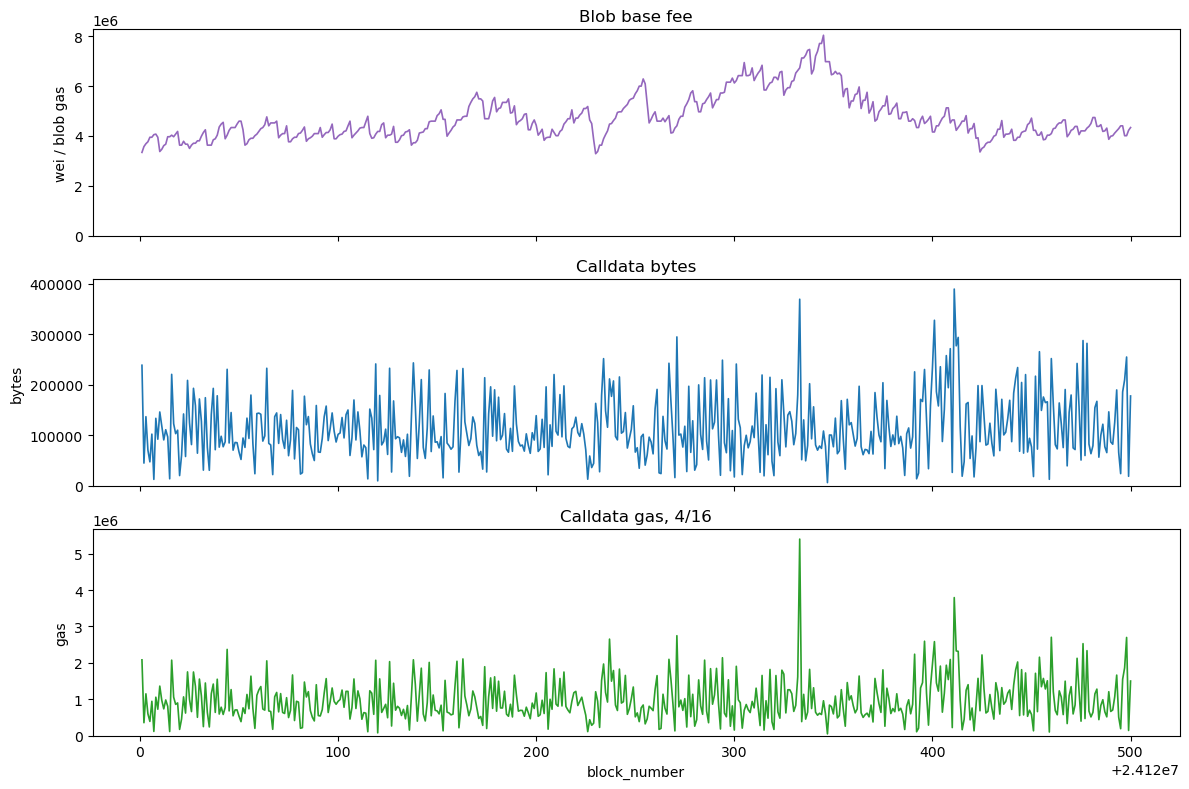

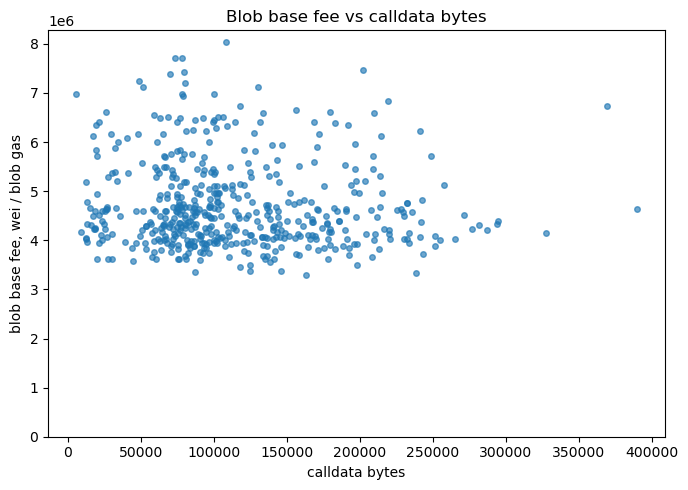

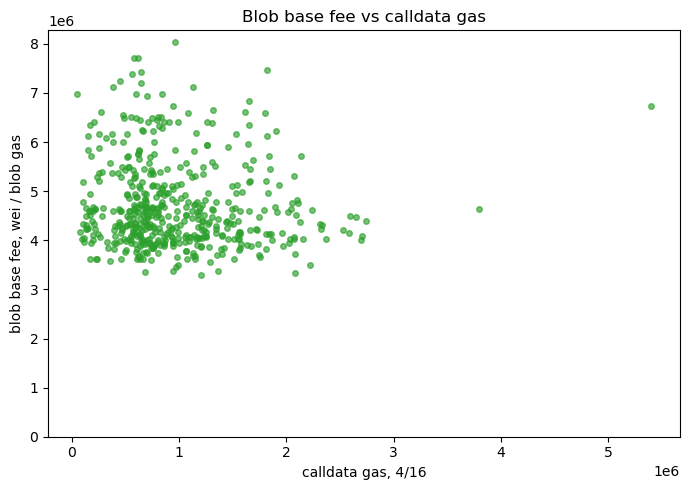

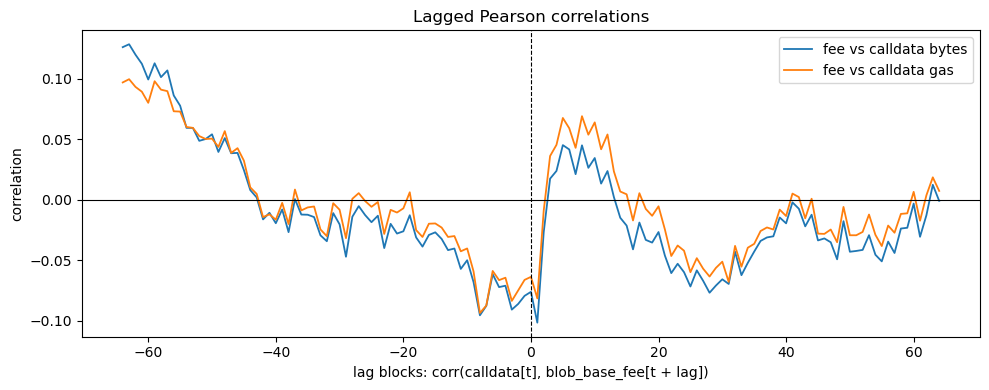

(PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/blob_base_fee_calldata_timeseries_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/blob_base_fee_calldata_bytes_scatter_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/blob_base_fee_calldata_gas_scatter_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/blob_base_fee_calldata_lag_correlations_24120001_24120500.png'))

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(joined["block_number"], joined["blob_base_fee_per_gas"], color="tab:purple", linewidth=1.2)
axes[0].set_title("Blob base fee")
axes[0].set_ylabel("wei / blob gas")
axes[0].set_ylim(bottom=0)

axes[1].plot(joined["block_number"], joined["calldata_bytes"], color="tab:blue", linewidth=1.2)
axes[1].set_title("Calldata bytes")
axes[1].set_ylabel("bytes")
axes[1].set_ylim(bottom=0)

axes[2].plot(joined["block_number"], joined["calldata_gas_4_16"], color="tab:green", linewidth=1.2)
axes[2].set_title("Calldata gas, 4/16")
axes[2].set_ylabel("gas")
axes[2].set_xlabel("block_number")
axes[2].set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(OUT_TIMESERIES_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(joined["calldata_bytes"], joined["blob_base_fee_per_gas"], s=16, alpha=0.65)
ax.set_title("Blob base fee vs calldata bytes")
ax.set_xlabel("calldata bytes")
ax.set_ylabel("blob base fee, wei / blob gas")
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(OUT_SCATTER_BYTES_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(joined["calldata_gas_4_16"], joined["blob_base_fee_per_gas"], s=16, alpha=0.65, color="tab:green")
ax.set_title("Blob base fee vs calldata gas")
ax.set_xlabel("calldata gas, 4/16")
ax.set_ylabel("blob base fee, wei / blob gas")
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(OUT_SCATTER_GAS_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag_corr["lag_blocks"], lag_corr["pearson_fee_vs_calldata_bytes"], label="fee vs calldata bytes", linewidth=1.3)
ax.plot(lag_corr["lag_blocks"], lag_corr["pearson_fee_vs_calldata_gas_4_16"], label="fee vs calldata gas", linewidth=1.3)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Lagged Pearson correlations")
ax.set_xlabel("lag blocks: corr(calldata[t], blob_base_fee[t + lag])")
ax.set_ylabel("correlation")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_LAG_PLOT, dpi=180)
plt.show()

OUT_TIMESERIES_PLOT, OUT_SCATTER_BYTES_PLOT, OUT_SCATTER_GAS_PLOT, OUT_LAG_PLOT

## Interpretation

For this 500-block window, the same-block correlation between blob base fee and calldata usage is weak. That is not too surprising: the blob base fee is a lagged state variable controlled by accumulated blob excess, while calldata bytes are same-block execution-payload usage.

The useful follow-up is to rerun this notebook on a much longer window, then split by regimes: low/high blob base fee, high blob count, high calldata blocks, and major L2 posting intervals.